In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score

In [2]:
df = pd.read_csv("Telco-Customer-Churn.csv")

In [3]:
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [4]:
print(df.columns)

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')


In [5]:
print(df.dtypes)

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [6]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [7]:
df.dropna(inplace=True)

In [8]:
df.drop("customerID", axis=1, inplace=True)

In [9]:
df["Churn"] = df["Churn"].replace({
    "Yes": 1,
    "No": 0
})

/tmp/ipykernel_494/2409374098.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Churn"] = df["Churn"].replace({


In [10]:
telecom_cust_dummies = pd.get_dummies(
    df,
    drop_first=True
)

telecom_cust_dummies.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


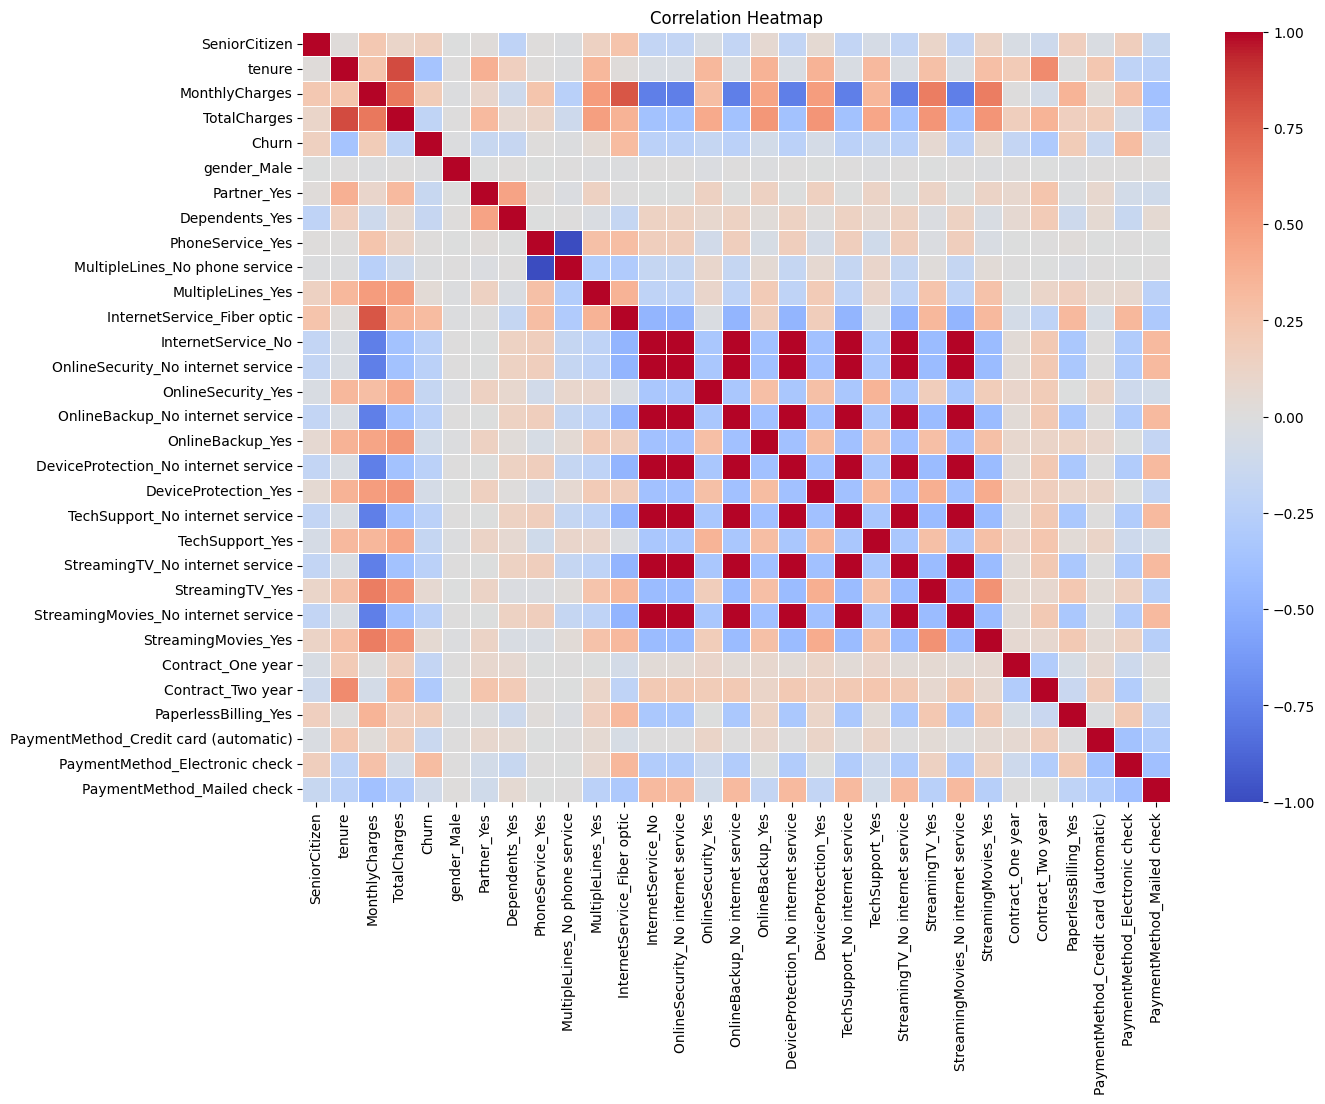

In [11]:
plt.figure(figsize=(14,10))

corr = telecom_cust_dummies.corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

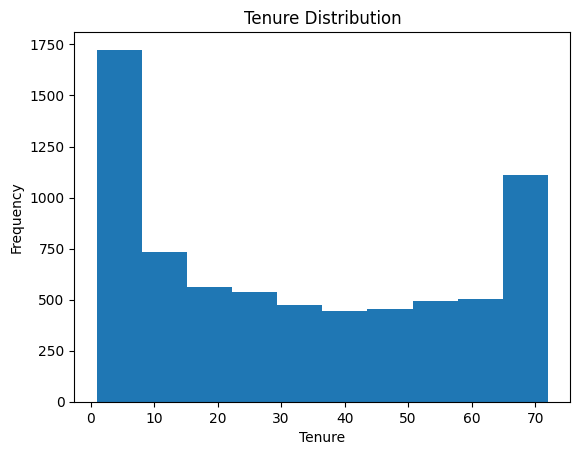

In [12]:
plt.figure()

plt.hist(df["tenure"])

plt.title("Tenure Distribution")
plt.xlabel("Tenure")
plt.ylabel("Frequency")

plt.show()

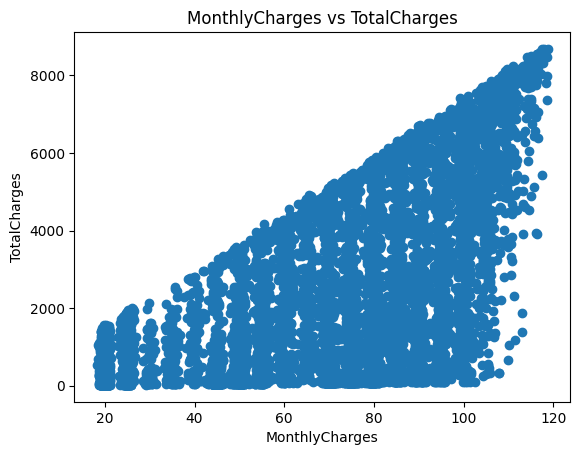

In [13]:
plt.figure()

plt.scatter(
    df["MonthlyCharges"],
    df["TotalCharges"]
)

plt.title("MonthlyCharges vs TotalCharges")
plt.xlabel("MonthlyCharges")
plt.ylabel("TotalCharges")

plt.show()

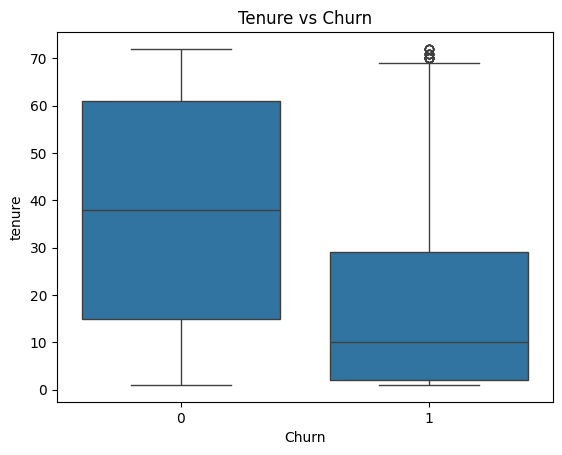

In [14]:
plt.figure()

sns.boxplot(
    x=df["Churn"],
    y=df["tenure"]
)

plt.title("Tenure vs Churn")

plt.show()

In [15]:
scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(
    telecom_cust_dummies
)

scaled_df = pd.DataFrame(
    scaled_data,
    columns=telecom_cust_dummies.columns
)

In [16]:
X = scaled_df.drop("Churn", axis=1)
y = scaled_df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

In [17]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(
    X_train,
    y_train
)

LogisticRegression(max_iter=1000)

In [18]:
y_pred_log = log_model.predict(X_test)

In [19]:
log_accuracy = accuracy_score(
    y_test,
    y_pred_log
)

print("Logistic Regression Accuracy:",
      log_accuracy)

Logistic Regression Accuracy: 0.7912400455062572


In [20]:
rf_model = RandomForestClassifier(
    n_estimators=2000,
    oob_score=True,
    max_features="sqrt",
    max_leaf_nodes=50,
    bootstrap=True,
    random_state=42
)

In [21]:
rf_model.fit(
    X_train,
    y_train
)

RandomForestClassifier(max_leaf_nodes=50, n_estimators=2000, oob_score=True,
                       random_state=42)

In [22]:
y_pred_rf = rf_model.predict(X_test)

In [23]:
rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

print("Random Forest Accuracy:",
      rf_accuracy)

Random Forest Accuracy: 0.7935153583617748


In [24]:
oob_error = 1 - rf_model.oob_score_

print("OOB Error:",
      oob_error)

OOB Error: 0.192643155100493


OOB Error Explanation:

The Out-of-Bag (OOB) error provides an internal estimate of model performance using data not included in each bootstrap sample.

The obtained OOB error of approximately 0.193 indicates that about 19.3% of predictions on unseen data may be incorrect. This relatively low error suggests that the random forest model generalises reasonably well to new, unseen data and is not severely overfitting.

In [25]:
cm_log = confusion_matrix(
    y_test,
    y_pred_log
)

cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

print("Logistic Regression Confusion Matrix:")
print(cm_log)

print("Random Forest Confusion Matrix:")
print(cm_rf)

Logistic Regression Confusion Matrix:
[[1154  146]
 [ 221  237]]
Random Forest Confusion Matrix:
[[1187  113]
 [ 250  208]]


In [26]:
# Logistic Regression

precision_log = precision_score(
    y_test,
    y_pred_log
)

recall_log = recall_score(
    y_test,
    y_pred_log
)

print("Logistic Precision:",
      precision_log)

print("Logistic Recall:",
      recall_log)


# Random Forest

precision_rf = precision_score(
    y_test,
    y_pred_rf
)

recall_rf = recall_score(
    y_test,
    y_pred_rf
)

print("Random Forest Precision:",
      precision_rf)

print("Random Forest Recall:",
      recall_rf)

Logistic Precision: 0.618798955613577
Logistic Recall: 0.517467248908297
Random Forest Precision: 0.6479750778816199
Random Forest Recall: 0.45414847161572053


Confusion Matrix Interpretation:

For the Logistic Regression model:
The model correctly predicted 1154 non-churn customers (True Negatives) and 237 churn customers (True Positives). However, 146 customers were incorrectly predicted as churn (False Positives), and 221 churn customers were missed (False Negatives).

For the Random Forest model:
The model correctly predicted 1187 non-churn customers and 208 churn customers. It produced 113 false positives and 250 false negatives.

The results show that both models perform well at identifying non-churn customers but struggle more with correctly identifying churn customers. This is reflected in the relatively higher number of false negatives.

Model Comparison:

The Random Forest model achieved slightly higher accuracy (0.7935) than the Logistic Regression model (0.7912). It also achieved higher precision, meaning it produced fewer false churn predictions.

However, Logistic Regression achieved higher recall, meaning it identified more actual churn customers.

Since detecting churn customers is particularly important in customer retention strategies, Logistic Regression may be slightly more useful when recall is prioritised. However, overall, Random Forest provides stronger predictive performance due to its higher accuracy and precision.

Therefore, the Random Forest model is generally more suitable for this task because of its better overall performance and ability to model complex relationships.